# ECON 398 Project Workbook

Authors: *William Clinton Co, Jerrold Huang, Jae Park, Kaiyan Zhang, Irene Berezin*

In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(haven)
library(lubridate)
library(stargazer)
library(units)
library(broom)
library(sf)
library(fixest)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.2"
Warning message:
"package 'dplyr' was built under R version 4.4.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 


udunits database from C:/Users/Kaiyan Zhang/AppData/Local/R/win-library/4.4/units/s

### Data Preprocessing (Pulling Data for 2021 Census)

In [2]:
# reading in cancensus data for 2021
library(cancensus)
options(cancensus.api_key='CensusMapper_85cff6944226682c2124e67a6d1cc29c')
options(cancensus.cache_path = "/census_api")

census2021 <- get_census(dataset='CA21', 
regions=list(CSD="5915022"), vectors=c("v_CA21_1","v_CA21_6","v_CA21_386","v_CA21_906","v_CA21_5901", "v_CA21_4410"), 
labels="detailed", 
geo_format="sf", 
level='DA',
use_cache = FALSE)

census2021_clean <- census2021|>
    rename(
        geoid = `GeoUID`,
        households = Households, 
        dwellings = Dwellings, 
        population =  `v_CA21_1: Population, 2021`,
        population_density = `v_CA21_6: Population density per square kilometre`, 
        region = `Region Name`, 
        area_sq_km = `Area (sq km)`, 
        age =  `v_CA21_386: Average age`, 
        income = `v_CA21_906: Median total income of household in 2020 ($)`,
        education = `v_CA21_5901: University certificate or diploma above bachelor level`,
        immigrant = `v_CA21_4410: Immigrants`    
    )|>
    filter(region == "Vancouver")|>
    mutate(immigrant_prop = immigrant/population) |>
    mutate(education_prop = education / population)|>
    mutate(income = income / 100000)|>
    select(name, households, dwellings, population,population_density, region, area_sq_km, age, income, immigrant_prop, education_prop)|>
    glimpse()

census2021_st <- st_sf(census2021_clean, geometry = census2021_clean$geometry, crs = 4326)
census2021_centroid <- st_centroid(census2021_clean)

Warning message:
"package 'cancensus' was built under R version 4.4.2"


Census data is currently stored temporarily.

 In order to speed up performance, reduce API quota usage, and reduce unnecessary network calls, please set up a persistent cache directory via `set_cancensus_cache_path('<local cache path>', install = TRUE)`.
 This will add your cache directory as environment varianble to your .Renviron to be used across sessions and projects.



Querying CensusMapper API...



Downloading: 26 kB     

Querying CensusMapper API...



Downloading: 260 kB     Rows: 0
Columns: 12
$ name               <chr> 
$ households         <int> 
$ dwellings          <int> 
$ population         <dbl> 
$ population_density <dbl> 
$ region             <fct> 
$ area_sq_km         <dbl> 
$ age                <dbl> 
$ income             <dbl> 
$ immigrant_prop     <dbl> 
$ education_prop     <dbl> 
$ geometry           <GEOMETRY [°]> 


### Data Exploration

In [2]:
# Read in the 2016 census data
census2016 <- read_sf("census_index_crime.geojson")|>
    select(- c(crime_count, crime_rate))|>
    glimpse()

Rows: 993
Columns: 17
$ name                 <chr> "59150307", "59150308", "59150309", "59150310", "…
$ households           <int> 254, 203, 269, 283, 181, 203, 402, 170, 333, 174,…
$ dwellings            <int> 273, 223, 299, 310, 199, 211, 418, 181, 356, 189,…
$ population           <int> 632, 501, 745, 536, 532, 562, 1088, 556, 959, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <int> 630, 500, 745, 540, 530, 560, 1085, 555, 960, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.4…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index     

In [3]:
# Read in the crime data
crime_data <- read.csv("Original_Crime_data/crime_in_vancouver_census.csv")|>
    select(type, year, month, name, neighbourhood, time_category)|>
    filter(!is.na(name))|>
    filter(year >= 2014 & year < 2025)|>
    glimpse()

Rows: 380,225
Columns: 6
$ type          <chr> "Break and Enter Commercial", "Break and Enter Commercia…
$ year          <int> 2019, 2019, 2021, 2014, 2020, 2021, 2022, 2014, 2014, 20…
$ month         <int> 3, 8, 4, 8, 7, 11, 1, 4, 9, 1, 11, 11, 3, 6, 9, 6, 2, 2,…
$ name          <int> 59153689, 59153483, 59153483, 59153483, 59153483, 591534…
$ neighbourhood <chr> "Fairview", "West End", "West End", "West End", "West En…
$ time_category <chr> "night", "night", "night", "night", "night", "night", "n…


In [4]:

crime_data <- crime_data|>
    group_by(year, month, name, type, time_category)|>
    summarise(crime_count = n(), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 207,379
Columns: 7
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150309, 591503…
$ type          <chr> "Theft of Vehicle", "Theft from Vehicle", "Mischief", "O…
$ time_category <chr> "night", "night", "day", "day", "night", "night", "night…
$ crime_count   <int> 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


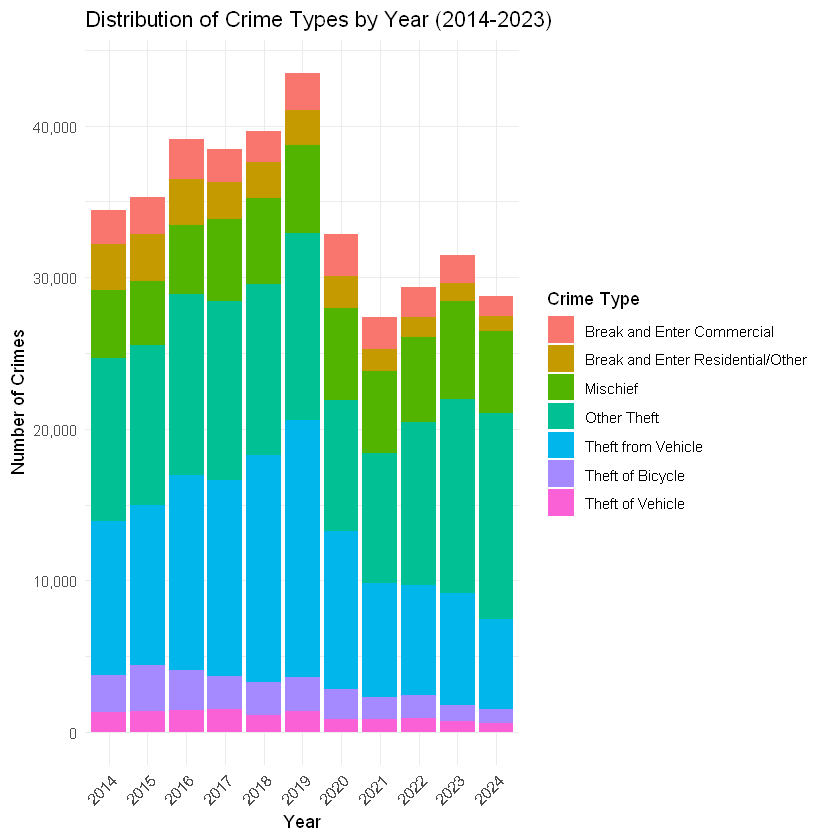

In [5]:
# Visualize the distribution of different types of crimes each year
crime_summary <- crime_data|>
  group_by(year, type)|>
  summarise(total_crimes = sum(crime_count, na.rm = TRUE))|>
  ungroup()

# Create the visualization
ggplot(crime_summary, aes(x = factor(year), y = total_crimes, fill = type)) +
  geom_col(position = "stack") +
  labs(title = "Distribution of Crime Types by Year (2014-2023)",
       x = "Year",
       y = "Number of Crimes",
       fill = "Crime Type") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "right") +
  scale_y_continuous(labels = scales::comma)

The visualization showed some promise in heterogeneous analysis by different crime types, but let's first focus on crime overall, we remove "Mischief" because it is something not so interesting for our study.

In [6]:
# Create a data summarizing all types of crimes together
crime_trend <- crime_data|>
    filter(type != "Mischief")|>
    group_by(year, month, name, time_category)|>
    summarise(crime_count = sum(crime_count), .groups = "drop")|>
    ungroup()|>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Rows: 112,655
Columns: 6
$ year          <int> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 20…
$ month         <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ name          <int> 59150307, 59150308, 59150309, 59150309, 59150310, 591503…
$ time_category <chr> "night", "night", "day", "night", "night", "night", "nig…
$ crime_count   <int> 1, 1, 1, 1, 4, 2, 1, 2, 1, 1, 3, 1, 2, 3, 1, 2, 3, 2, 1,…
$ date          <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014-01…


In [7]:
census2016_panel <- merge(census2016, crime_trend, by = "name")|>
    arrange(year, month)|>
    glimpse()

Rows: 112,655
Columns: 22
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [8]:
neighborhood <- read_sf("Boundary_data/local-area-boundary.geojson")|>
    rename("neighborhood" = "name")|>
    st_sf()

neighborhood_valid <- st_make_valid(neighborhood)
census2016_panel <- st_make_valid(census2016_panel)


# Compute centroids for census divisions
census2016_centroids <- st_centroid(census2016_panel)

# Perform a spatial join based on whether the census centroid is within the neighborhood boundary
census2016_centroids_joined <- st_join(census2016_centroids, neighborhood_valid[, "neighborhood"], join = st_within)

census2016_panel$neighborhood <- census2016_centroids_joined$neighborhood

glimpse(census2016_panel)


Warning message:
"st_centroid assumes attributes are constant over geometries"


Rows: 112,655
Columns: 23
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

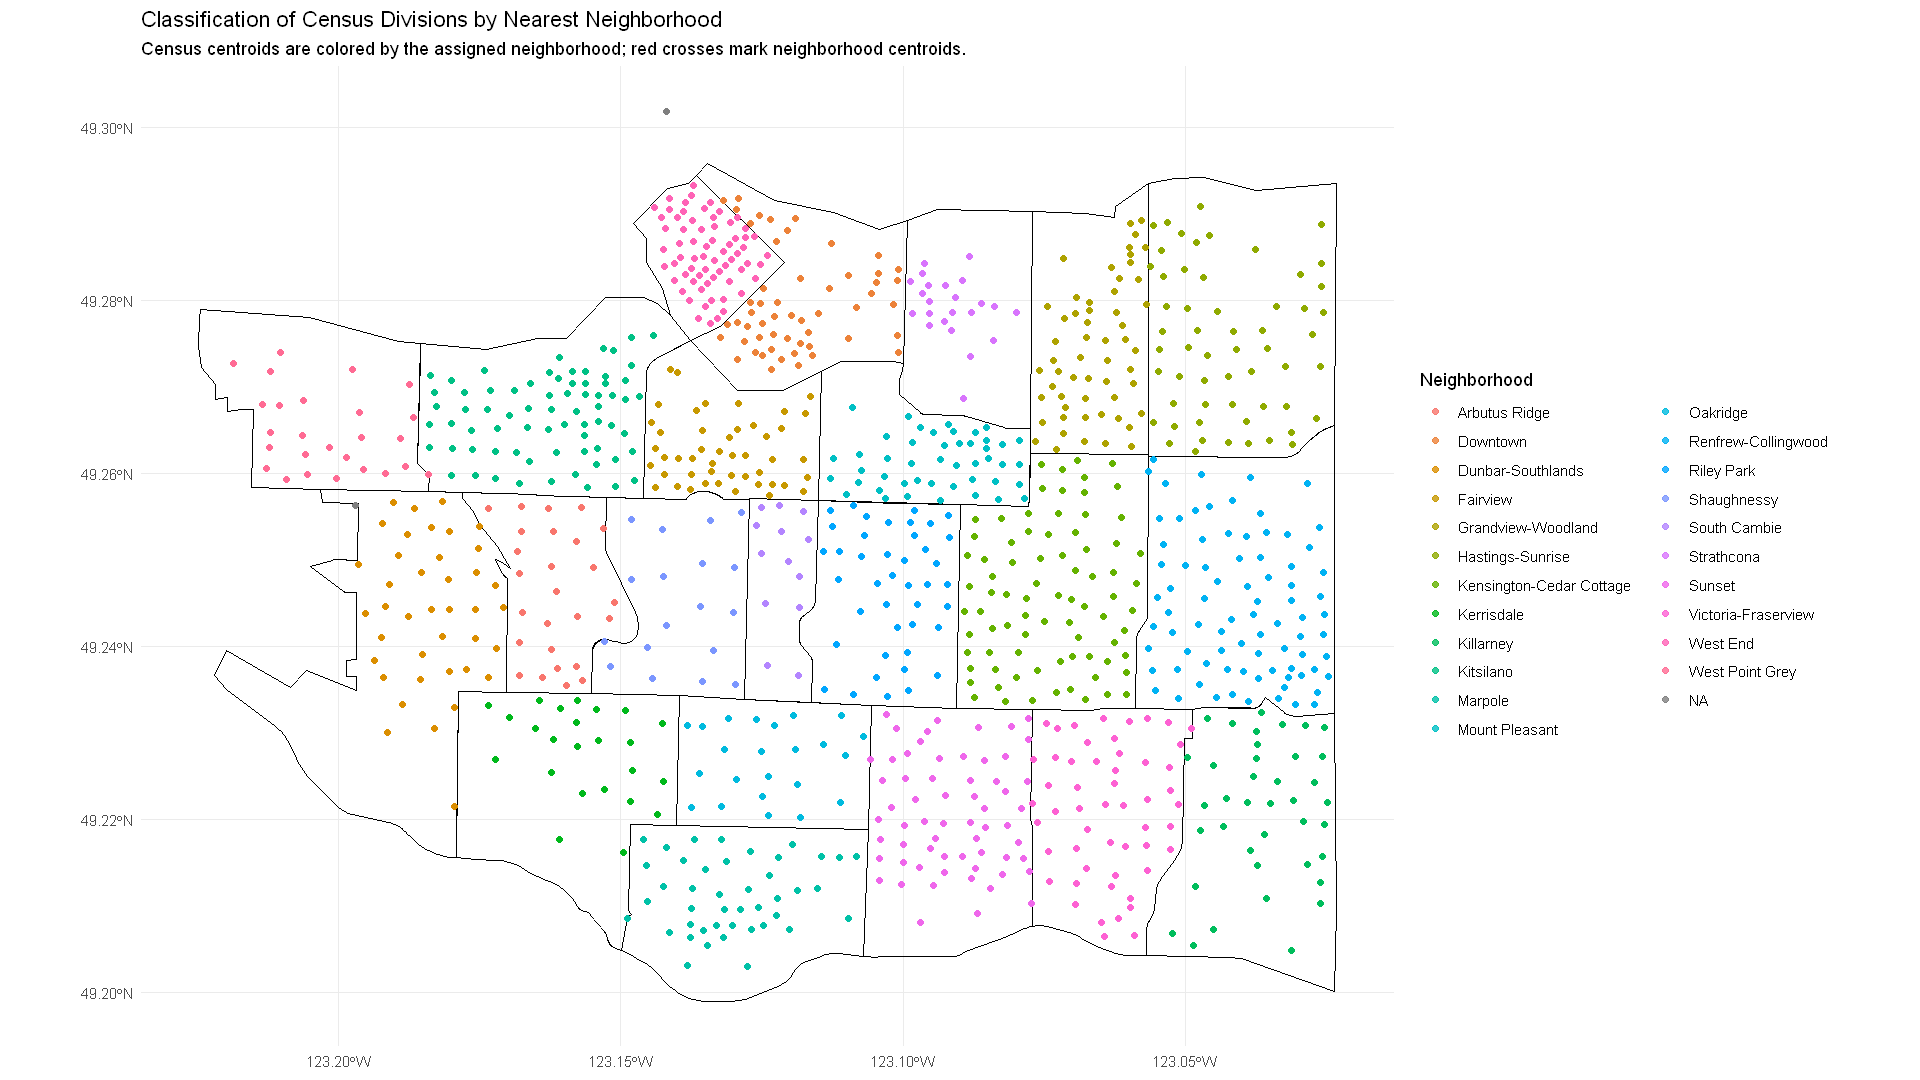

In [10]:
census2016_centroids <- census2016_centroids %>%
  mutate(neighborhood = census2016_panel$neighborhood)

options(repr.plot.width = 16, repr.plot.height = 9)

# Create the plot of neighborhood
ggplot() +
  geom_sf(data = neighborhood_valid, fill = NA, color = "black", lwd = 0.5) +
  geom_sf(data = census2016_centroids, aes(color = neighborhood), size = 1.5, alpha = 0.8) +
  scale_fill_grey(start = 0.2, end = 0.9) + 
  labs(title = "Classification of Census Divisions by Nearest Neighborhood",
       subtitle = "Census centroids are colored by the assigned neighborhood; red crosses mark neighborhood centroids.",
       color = "Neighborhood") +
  theme_minimal()

In [11]:
# Read in the NASA NTL data
ntl_data <- read_csv("NTL_data/NASA_ntl_2012_2024_monthly.csv")|>
    filter(!is.na(ntl_mean))|>
    select(!c(population, population_density))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    glimpse()

ntl_data$name <- as.character(ntl_data$name)

Rows: 154908 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): date
dbl (7): name, population, population_density, ntl_mean, n_pixels, n_non_na_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 141,792
Columns: 6
$ name               <dbl> 59150307, 59150309, 59150311, 59150313, 59150328, 5…
$ ntl_mean           <dbl> 3.710000, 3.020000, 3.971038, 4.609642, 4.880000, 4…
$ n_pixels           <dbl> 5, 4, 4, 4, 3, 8, 4, 4, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ n_non_na_pixels    <dbl> 1, 1, 2, 2, 1, 4, 4, 3, 4, 4, 4, 4, 6, 3, 3, 3, 4, …
$ prop_non_na_pixels <dbl> 0.2000000, 0.2500000, 0.5000000, 0.5000000, 0.33333…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [12]:
# Merge 2 dataframes
census2016_panel <- census2016_panel|>
    left_join(ntl_data, by = c("name", "date"))|>
    glimpse()

Rows: 112,655
Columns: 27
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [13]:
crime_summary <- census2016_panel|>
    st_drop_geometry()|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

crime_summary

mean,variance,min,max
<dbl>,<dbl>,<int>,<int>
2.849949,47.61759,1,213


Since the crime data is highly volatile and affected by a lot of empty bins, and apparently it has a much larger variance comparing to its mean value. So instead of using the raw variable, we would employ a negative binomial regression to find its expected value given fixed effects of year, month, division, time_category, and we are using population density as an offset variable. 

In [14]:
census2016_panel <- census2016_panel|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    glimpse()

Rows: 112,655
Columns: 28
$ name                 <chr> "59150307", "59150308", "59150309", "59150309", "…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [15]:
# load the necessary library
library(MASS)

# Coverting fixed effects as factors
census2016_panel$name <- as.factor(census2016_panel$name)
census2016_panel$year <- as.factor(census2016_panel$year)
census2016_panel$month <- as.factor(census2016_panel$month)
census2016_panel$time_category <- as.factor(census2016_panel$time_category)
census2016_panel$neighborhood <- as.factor(census2016_panel$neighborhood)

# Implementing the negative binomial regression
model_nb <- glm.nb(crime_count ~ name + year + month + time_category + offset(log(population_density)),
                   data = census2016_panel)

summary(model_nb)

Warning message:
"package 'MASS' was built under R version 4.4.2"

Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select





Call:
glm.nb(formula = crime_count ~ name + year + month + time_category + 
    offset(log(population_density)), data = census2016_panel, 
    init.theta = 22.91864886, link = log)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)        -7.3293880  0.0788920 -92.904  < 2e-16 ***
name59150308       -0.8010912  0.1162084  -6.894 5.44e-12 ***
name59150309       -1.0855303  0.1018511 -10.658  < 2e-16 ***
name59150310       -0.5776584  0.0952820  -6.063 1.34e-09 ***
name59150311       -1.3271977  0.1169711 -11.346  < 2e-16 ***
name59150312       -1.2123833  0.1178710 -10.286  < 2e-16 ***
name59150313       -0.9216212  0.1082610  -8.513  < 2e-16 ***
name59150328       -0.1989466  0.1137848  -1.748 0.080387 .  
name59150329       -0.4006145  0.1087209  -3.685 0.000229 ***
name59150330       -1.2967576  0.1505344  -8.614  < 2e-16 ***
name59150331       -0.9787384  0.1178975  -8.302  < 2e-16 ***
name59150332       -1.2372170  0.1241795  -9.963  < 2e-16 *

In [16]:
census2016_panel$expected_crime <- predict(model_nb, type = "response")

glimpse(census2016_panel)

Rows: 112,655
Columns: 29
$ name                 <fct> 59150307, 59150308, 59150309, 59150309, 59150310,…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [17]:
NBsummary <- census2016_panel|>
    st_drop_geometry()|>
    group_by(time_category)|>
    summarise(mean = mean(expected_crime),
    variance = var(expected_crime),
    min = min(expected_crime),
    max = max(expected_crime))

NBsummary

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
day,2.814127,39.45146,0.7520295,119.3935
night,2.873353,41.57980,0.9028699,146.1237


In [18]:
# Read in data for electric price index
electric_index <- read_csv("electric_price_index.csv")|>
    dplyr::select(REF_DATE, Index, VALUE)|>
    filter(Index == "Electric power selling price under 5000kw")|>
    mutate(date = as.Date(paste0(REF_DATE, "-01")))|>
    rename("electric_index" = "VALUE")|>
    dplyr::select(date, electric_index)|>
    glimpse()

Rows: 264 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (7): REF_DATE, GEO, DGUID, Index, UOM, SCALAR_FACTOR, VECTOR
dbl (5): UOM_ID, SCALAR_ID, COORDINATE, VALUE, DECIMALS
lgl (3): STATUS, SYMBOL, TERMINATED

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 132
Columns: 2
$ date           <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 2014-0…
$ electric_index <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7, 10…


In [19]:
census2016_panel <- census2016_panel|>
    left_join(electric_index, by = "date")|>
    glimpse()

Rows: 112,655
Columns: 30
$ name                 <fct> 59150307, 59150308, 59150309, 59150309, 59150310,…
$ households           <int> 254, 203, 269, 269, 283, 181, 203, 402, 174, 174,…
$ dwellings            <int> 273, 223, 299, 299, 310, 199, 211, 418, 189, 189,…
$ population           <int> 632, 501, 745, 745, 536, 532, 562, 1088, 506, 506…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 6663.7, 4895.0, 6567.9, 6…
$ region               <chr> "Vancouver", "Vancouver", "Vancouver", "Vancouver…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.11190, 0.10940, 0.08…
$ age                  <int> 630, 500, 745, 745, 540, 530, 560, 1085, 510, 510…
$ income               <chr> "0.90964999999999996", "0.93611", "0.84736", "0.8…
$ immigrant_prop       <chr> "0.26107590000000003", "0.28942119999999999", "0.…
$ education_prop       <chr> "0.30854429999999999", "0.2794411", "0.3154362", …
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 1.426336, 2.441091,…
$ light_index 

In [20]:
# Save the data so we can start from here next time
census2016_panel <- census2016_panel|>
    st_drop_geometry()|>
    dplyr::select(-c(households, dwellings, region))

write_csv(census2016_panel, "census_2016_panel.csv")

#### Wrapping neighborhood data

In [29]:
# Generate the dataset on 22 neighborhood
neighborhood2016_panel <- census2016_panel |>
    filter(name != "59153586") |>  # Remove Stanley Park
    mutate(income = as.double(income)) |>
    filter(!is.na(income)) |>
    # Create separate month and year columns
    group_by(neighborhood, year, month, time_category) |>
    summarise(
        population = sum(population),
        area_sq_km = sum(area_sq_km),
        population_density = population / area_sq_km,
        income = mean(income),
        crime_count = sum(crime_count),
        electric_index = mean(electric_index, na.rm = TRUE),
        .groups = "drop"
    ) |>
    mutate(date = as.Date(paste(year, month, "01", sep = "-")))|>
    glimpse()

Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `income = as.double(income)`.
Caused by warning:
! NAs introduced by coercion"


Rows: 5,883
Columns: 11
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <int> 4081, 8092, 1969, 7398, 4209, 5580, 4198, 7826, 451…
$ area_sq_km         <dbl> 1.27478, 1.73506, 0.46015, 1.90694, 0.89528, 1.2035…
$ population_density <dbl> 3201.337, 4663.816, 4279.039, 3879.514, 4701.322, 4…
$ income             <dbl> 0.8331200, 0.7900292, 0.9015467, 0.8405400, 0.79670…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 94.8, 94.8, 94.8, 101.7, 101.7, 1…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…


In [30]:
neighborhood_ntl <- read_csv("NTL_data/22_ntl_2012_2024_monthly.csv")|>
    rename("neighborhood" = "name")|>
    filter(!is.na(ntl_mean))|>
    mutate(date = as.Date(paste0(date, "-01")))|>
    dplyr::select(!geo_point_2d)|>
    glimpse()

Rows: 3432 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): name, geo_point_2d, date
dbl (4): ntl_mean, n_pixels, n_non_na_pixels, prop_non_na_pixels

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3,146
Columns: 6
$ neighborhood       <chr> "Downtown", "Hastings-Sunrise", "Kerrisdale", "Marp…
$ ntl_mean           <dbl> 15.101049, 3.424347, 2.195419, 4.155951, 3.277409, …
$ n_pixels           <dbl> 54, 71, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 69,…
$ n_non_na_pixels    <dbl> 54, 53, 65, 54, 44, 50, 24, 43, 48, 95, 42, 42, 45,…
$ prop_non_na_pixels <dbl> 1.0000000, 0.7464789, 1.0000000, 1.0000000, 1.00000…
$ date               <date> 2012-01-01, 2012-01-01, 2012-01-01, 2012-01-01, 20…


In [31]:
neighborhood2016_panel <- neighborhood2016_panel|>
    left_join(neighborhood_ntl, by = c("neighborhood", "date"))|>
    mutate(is_downtown = ifelse(neighborhood == "Downtown", 1, 0))|>
    filter(!is.na(neighborhood))|>
    glimpse()

Rows: 5,807
Columns: 16
$ neighborhood       <chr> "Arbutus Ridge", "Arbutus Ridge", "Arbutus Ridge", …
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <int> 4081, 8092, 1969, 7398, 4209, 5580, 4198, 7826, 451…
$ area_sq_km         <dbl> 1.27478, 1.73506, 0.46015, 1.90694, 0.89528, 1.2035…
$ population_density <dbl> 3201.337, 4663.816, 4279.039, 3879.514, 4701.322, 4…
$ income             <dbl> 0.8331200, 0.7900292, 0.9015467, 0.8405400, 0.79670…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 94.8, 94.8, 94.8, 101.7, 101.7, 1…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.041108, 3.063007, 3.063007, 3.580293, 3…
$ n_pixels      

In [32]:
neighborhood_crime_summary <- neighborhood2016_panel|>
    summarise(mean = mean(crime_count),
    variance = var(crime_count),
    min = min(crime_count),
    max = max(crime_count))

neighborhood_crime_summary

mean,variance,min,max
<dbl>,<dbl>,<int>,<int>
54.77562,6339.545,1,690


In [35]:
# Coverting fixed effects as factors
neighborhood2016_panel$neighborhood <- as.factor(neighborhood2016_panel$neighborhood)

# Implementing the negative binomial regression
neighborhood_model_nb <- glm.nb(crime_count ~ neighborhood + year + month + time_category + offset(log(population_density)),
                   data = neighborhood2016_panel)

summary(neighborhood_model_nb)


Call:
glm.nb(formula = crime_count ~ neighborhood + year + month + 
    time_category + offset(log(population_density)), data = neighborhood2016_panel, 
    init.theta = 14.13849082, link = log)

Coefficients:
                                      Estimate Std. Error  z value Pr(>|z|)    
(Intercept)                          -6.058450   0.031603 -191.707  < 2e-16 ***
neighborhoodDowntown                  2.161117   0.029654   72.878  < 2e-16 ***
neighborhoodDunbar-Southlands         0.725611   0.033527   21.643  < 2e-16 ***
neighborhoodFairview                  0.951700   0.030564   31.137  < 2e-16 ***
neighborhoodGrandview-Woodland        1.345714   0.030655   43.899  < 2e-16 ***
neighborhoodHastings-Sunrise          1.279156   0.031341   40.814  < 2e-16 ***
neighborhoodKensington-Cedar Cottage  0.955111   0.030773   31.037  < 2e-16 ***
neighborhoodKerrisdale                0.572169   0.033975   16.841  < 2e-16 ***
neighborhoodKillarney                 0.755193   0.032221   23.438  <

In [34]:
neighborhood2016_panel$expected_crime <- predict(neighborhood_model_nb, type = "response")

glimpse(neighborhood2016_panel)

Rows: 5,807
Columns: 17
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, …
$ time_category      <fct> day, night, day, night, day, night, day, night, day…
$ population         <int> 4081, 8092, 1969, 7398, 4209, 5580, 4198, 7826, 451…
$ area_sq_km         <dbl> 1.27478, 1.73506, 0.46015, 1.90694, 0.89528, 1.2035…
$ population_density <dbl> 3201.337, 4663.816, 4279.039, 3879.514, 4701.322, 4…
$ income             <dbl> 0.8331200, 0.7900292, 0.9015467, 0.8405400, 0.79670…
$ crime_count        <int> 10, 17, 3, 19, 8, 11, 9, 22, 11, 24, 11, 31, 11, 17…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 94.8, 94.8, 94.8, 101.7, 101.7, 1…
$ date               <date> 2014-01-01, 2014-01-01, 2014-02-01, 2014-02-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.041108, 3.063007, 3.063007, 3.580293, 3…
$ n_pixels      

In [36]:
NBsummary_neighborhood <- neighborhood2016_panel|>
    group_by(time_category)|>
    summarise(mean = mean(expected_crime),
    variance = var(expected_crime),
    min = min(expected_crime),
    max = max(expected_crime))

NBsummary_neighborhood

time_category,mean,variance,min,max
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
day,42.99510,3578.128,1.728664,398.6649
night,68.03864,8703.302,5.338644,634.9640


In [37]:
write_csv(neighborhood2016_panel, "neighborhood2016_panel.csv")

### Panel Fixed Effect Model

#### Models on 989 Census Divisions

With the data ready, we can run our first panel fixed effect model.

In [38]:
census2016_panel <- read_csv("census_2016_panel.csv")

Rows: 112655 Columns: 26
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): time_category, neighborhood
dbl  (23): name, population, population_density, area_sq_km, age, income, im...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [39]:
# Making necessary changes to the data
census2016_panel_night <- census2016_panel|>
    filter(time_category == "night")|>
    filter(year %in% c(2014, 2015, 2016, 2017, 2018))|>
    mutate(month = factor(month, levels = c("6", setdiff(sort(unique(as.character(month))), "6"))))|>
    mutate(year = as.factor(year))|>
    mutate(income = as.numeric(income), immigrant_prop = as.numeric(immigrant_prop), education_prop = as.numeric(education_prop))|>
    mutate(is_downtown = ifelse(is.na(is_downtown), 0, is_downtown))|>
    filter(!is.na(income), !is.na(education_prop), !is.na(immigrant_prop))|>
    glimpse()

Rows: 33,059
Columns: 26
$ name                 <dbl> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 506, 683, 618…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 510, 680, 620…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ education_prop       <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 3.239346, 2.298736,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 3.605736, 1.782943,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.382670, 1.501593,…
$ mean_land_val

In [40]:
# Adding day crime as a control
census2016_panel_day <- census2016_panel|>
    filter(time_category == "day")|>
    filter(year %in% c(2014, 2015, 2016, 2017, 2018))|>
    mutate(day_crime_count = crime_count, expected_day_crime = expected_crime)|>
    dplyr::select(name, date, day_crime_count, expected_day_crime)

census2016_panel_night <- census2016_panel_night|>
    left_join(census2016_panel_day, by = c("name", "date"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    mutate(expected_day_crime = ifelse(is.na(expected_day_crime), 0, expected_day_crime))|>
    glimpse()

Rows: 33,059
Columns: 28
$ name                 <dbl> 59150307, 59150308, 59150309, 59150310, 59150311,…
$ population           <dbl> 632, 501, 745, 536, 532, 562, 1088, 506, 683, 618…
$ population_density   <dbl> 2110.9, 4575.3, 6663.7, 4895.0, 6567.9, 6445.0, 6…
$ area_sq_km           <dbl> 0.29926, 0.10956, 0.11190, 0.10940, 0.08094, 0.08…
$ age                  <dbl> 630, 500, 745, 540, 530, 560, 1085, 510, 680, 620…
$ income               <dbl> 0.90965, 0.93611, 0.84736, 0.45184, 0.82517, 0.74…
$ immigrant_prop       <dbl> 0.2610759, 0.2894212, 0.3557047, 0.2891791, 0.404…
$ education_prop       <dbl> 0.3085443, 0.2794411, 0.3154362, 0.1865672, 0.253…
$ school_index         <dbl> 1.074675, 1.252273, 1.426336, 2.441091, 1.543095,…
$ light_index          <dbl> 2.751678, 2.575631, 2.986096, 3.239346, 2.298736,…
$ bus_index            <dbl> 1.314003, 1.455674, 1.812310, 3.605736, 1.782943,…
$ cultural_space_index <dbl> 1.286579, 1.349792, 1.485976, 1.382670, 1.501593,…
$ mean_land_val

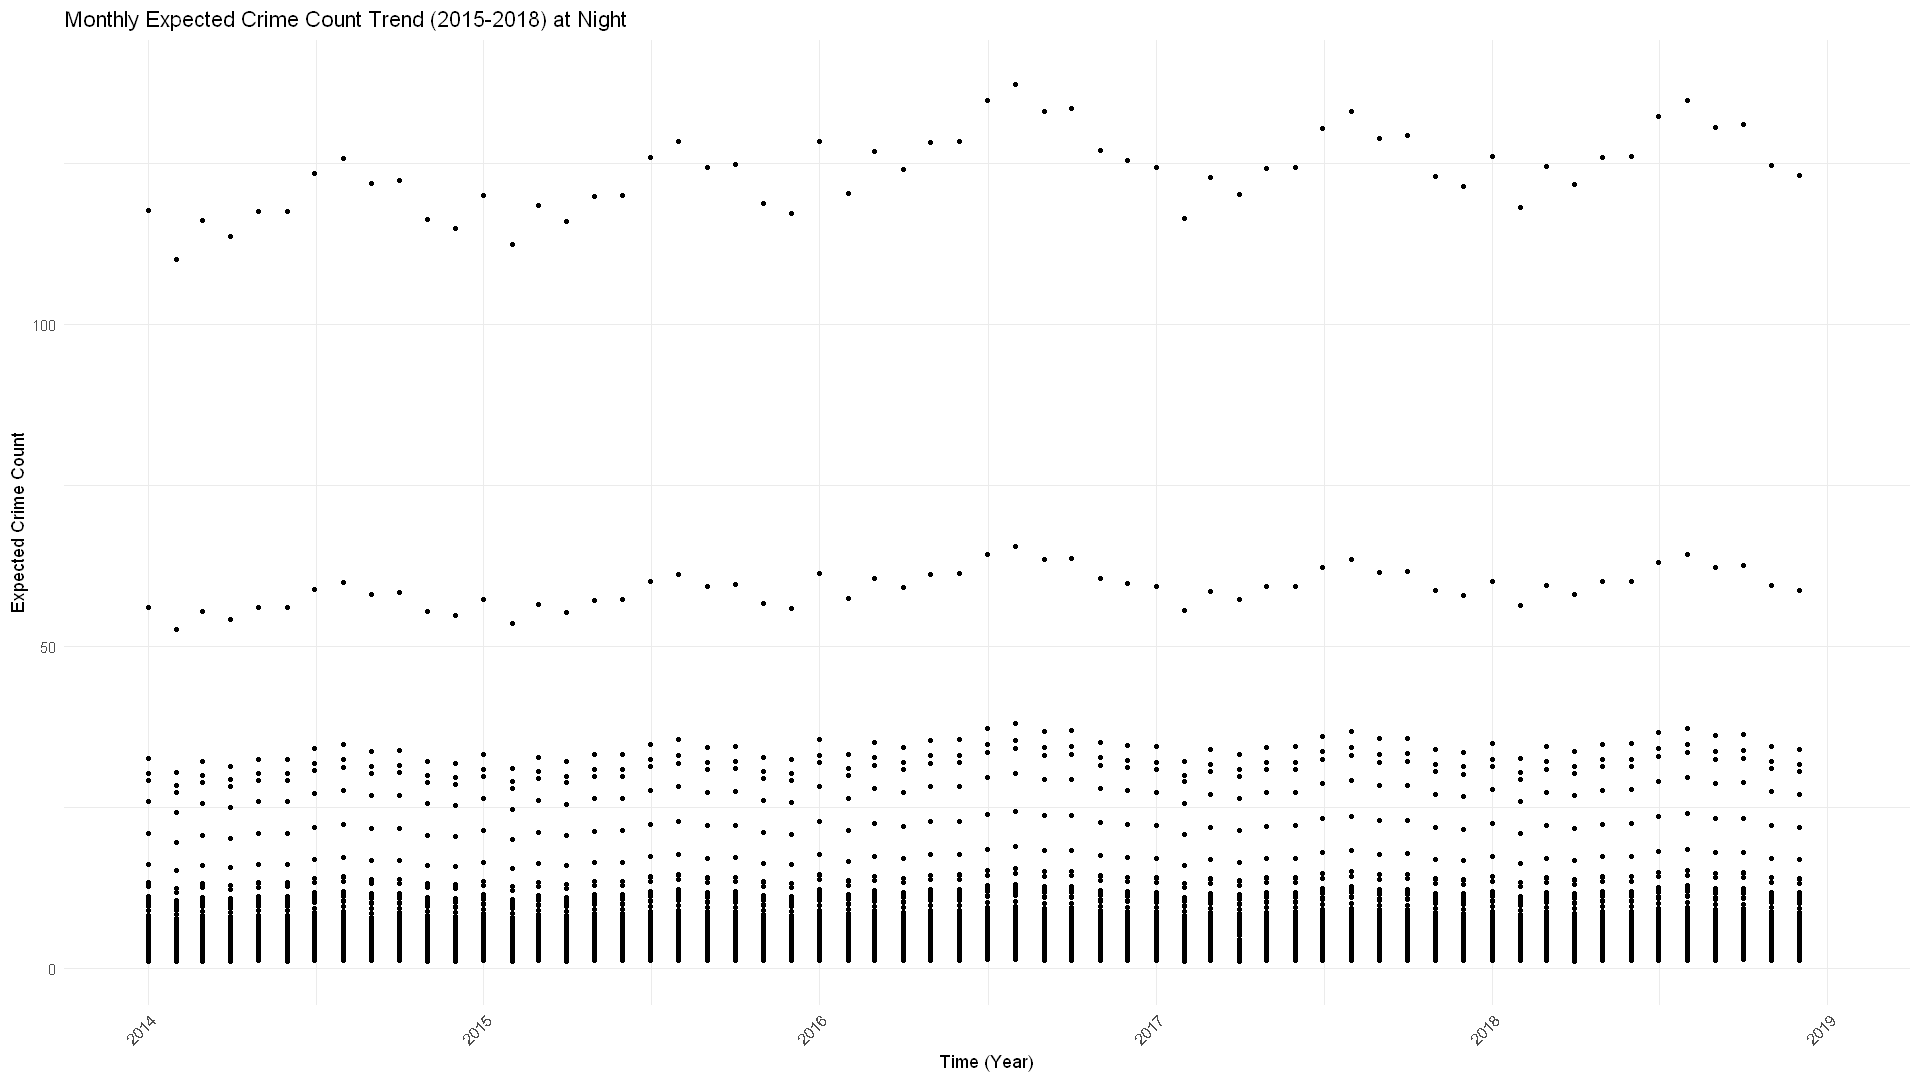

In [41]:
ggplot(census2016_panel_night, aes(x = date, y = expected_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2015-2018) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

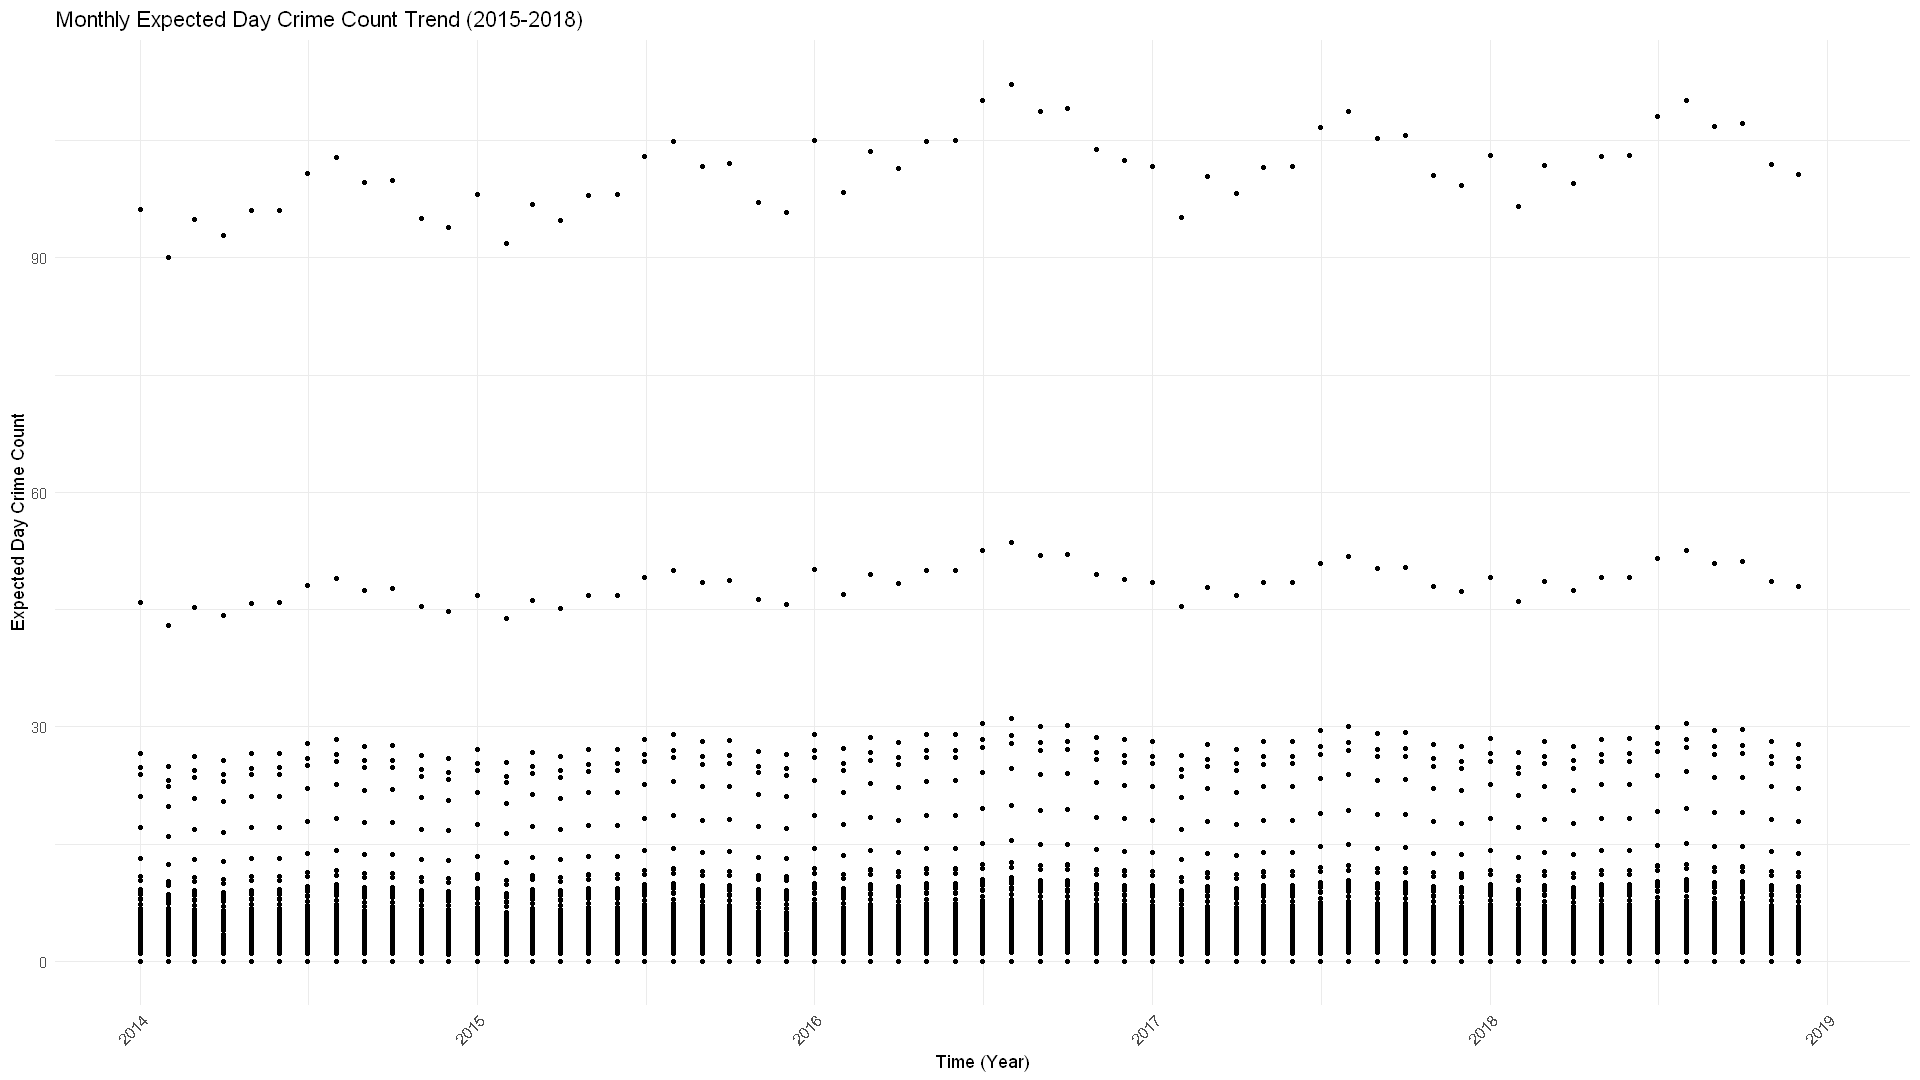

In [42]:
ggplot(census2016_panel_night, aes(x = date, y = expected_day_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Day Crime Count", 
       title = "Monthly Expected Day Crime Count Trend (2015-2018)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 2667 rows containing non-finite outside the scale range
(`stat_smooth()`)."
Warning message:
"Removed 2667 rows containing missing values or values outside the scale range
(`geom_point()`)."


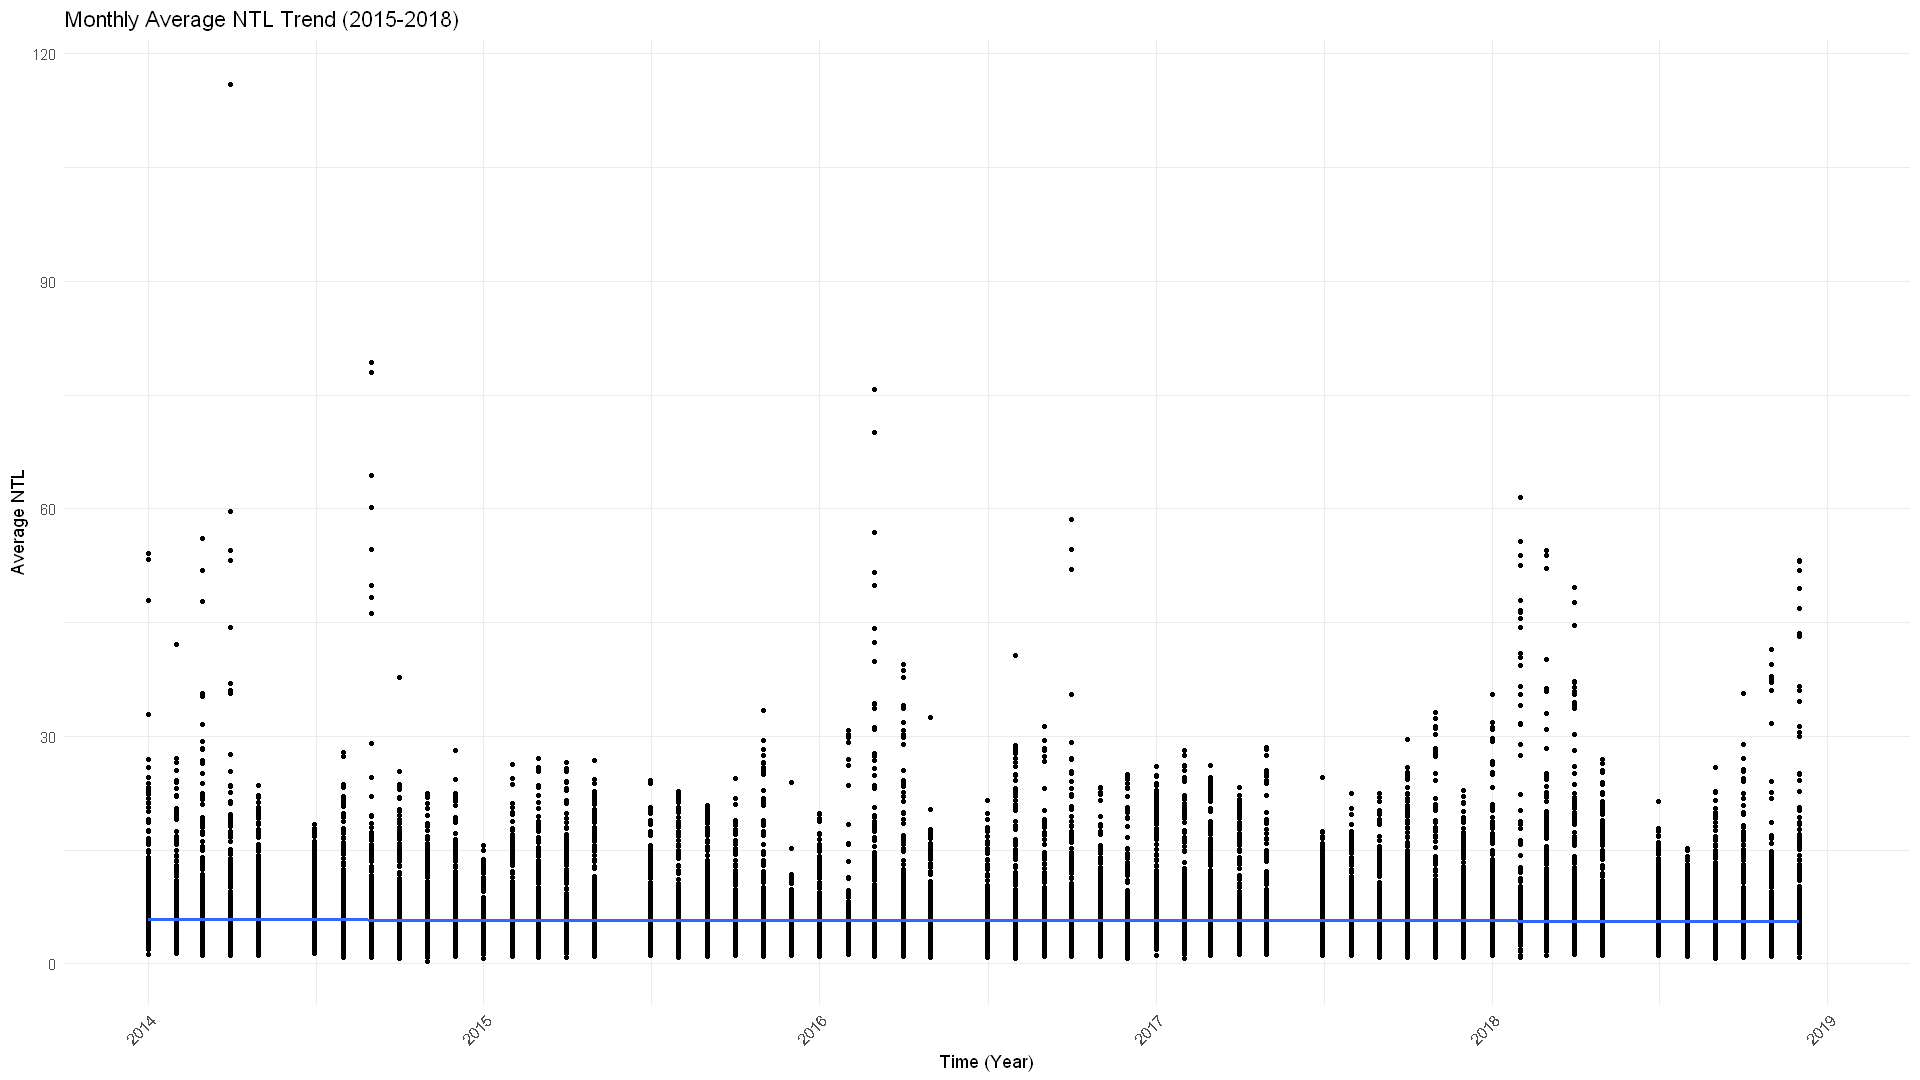

In [43]:
ggplot(census2016_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2015-2018)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [44]:
library(plm)

Warning message:
"package 'plm' was built under R version 4.4.3"

Attaching package: 'plm'


The following objects are masked from 'package:dplyr':

    between, lag, lead




In [45]:
model0 <- plm(expected_crime ~ ntl_mean * is_downtown + year + month, 
                            index = c("name", "date"),
                             data = census2016_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(model0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + year + 
    month, data = census2016_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 4-55, N = 30392

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-13.1863809  -0.0406769  -0.0029378   0.0426512  13.2963936 

Coefficients:
                       Estimate Std. Error  t-value  Pr(>|t|)    
ntl_mean              0.0017028  0.0016308   1.0441 0.2964368    
year2015              0.0601520  0.0060940   9.8707 < 2.2e-16 ***
year2016              0.2606643  0.0060840  42.8439 < 2.2e-16 ***
year2017              0.1631949  0.0060745  26.8655 < 2.2e-16 ***
year2018              0.2077584  0.0060276  34.4676 < 2.2e-16 ***
month10               0.1185347  0.0087355  13.5693 < 2.2e-16 ***
month11              -0.0288298  0.0087658  -3.2889 0.0010069 ** 
month12              -0.0645712  0.0087653  -7.36

In [90]:
model1 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime + month, 
                            index = c("name", "date"),
                             data = census2016_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model1)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    month, data = census2016_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 4-55, N = 30392

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-11.4363166  -0.1151628   0.0092289   0.1020774  11.5122122 

Coefficients:
                       Estimate Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.0054256  0.0015498  -3.5009 0.0004644 ***
expected_day_crime    0.1745020  0.0025063  69.6256 < 2.2e-16 ***
month10               0.0784175  0.0084417   9.2893 < 2.2e-16 ***
month11              -0.0430948  0.0084558  -5.0965 3.482e-07 ***
month12              -0.0759000  0.0084531  -8.9790 < 2.2e-16 ***
month2               -0.1675770  0.0087296 -19.1963 < 2.2e-16 ***
month3               -0.0394289  0.0086959  -4.5342 5.805e-06 ***
month4               -0.1063572  0.

In [91]:
model2 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime + month + electric_index + population_density, 
                            index = c("name", "date"),
                             data = census2016_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model2)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    month + electric_index + population_density, data = census2016_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 4-55, N = 30392

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-11.3607153  -0.1080556   0.0061203   0.0962153  11.5602893 

Coefficients:
                        Estimate  Std. Error  t-value  Pr(>|t|)    
ntl_mean             -0.00405948  0.00151052  -2.6875 0.0072036 ** 
expected_day_crime    0.16912673  0.00244591  69.1466 < 2.2e-16 ***
month10               0.02948428  0.00831809   3.5446 0.0003938 ***
month11              -0.09499151  0.00834316 -11.3856 < 2.2e-16 ***
month12              -0.12760238  0.00833974 -15.3005 < 2.2e-16 ***
month2               -0.16867400  0.00850623 -19.8295 < 2.2e-16 ***
month3               -0.04123198  0.0084

In [92]:
model_log0 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + month, 
                            index = c("name", "date"),
                             data = census2016_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + month, data = census2016_panel_night, 
    effect = "individual", model = "within", index = c("name", 
        "date"))

Unbalanced Panel: n = 992, T = 4-55, N = 30392

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.0943932 -0.0300432  0.0087651  0.0262242  0.0732986 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -0.02239836  0.00096267 -23.2670 < 2.2e-16 ***
expected_day_crime         0.00312029  0.00025332  12.3178 < 2.2e-16 ***
month10                    0.03642275  0.00085351  42.6739 < 2.2e-16 ***
month11                   -0.01491487  0.00085621 -17.4196 < 2.2e-16 ***
month12                   -0.02889146  0.00085614 -33.7463 < 2.2e-16 ***
month2                    -0.06292494  0.00088433 -71.1553 < 2.2e-16 ***
month3                    -0.00956295  0.00

In [93]:
model_log1 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + month + electric_index + population_density, 
                            index = c("name", "date"),
                             data = census2016_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + month + electric_index + population_density, 
    data = census2016_panel_night, effect = "individual", model = "within", 
    index = c("name", "date"))

Unbalanced Panel: n = 992, T = 4-55, N = 30392

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-0.03820114 -0.01110667 -0.00725465 -0.00058353  0.05483489 

Coefficients:
                             Estimate  Std. Error   t-value  Pr(>|t|)    
log(ntl_mean)             -1.4871e-02  5.5717e-04  -26.6893 < 2.2e-16 ***
expected_day_crime         1.1642e-03  1.4661e-04    7.9409 2.079e-15 ***
month10                    1.8328e-02  4.9886e-04   36.7397 < 2.2e-16 ***
month11                   -3.3570e-02  5.0075e-04  -67.0394 < 2.2e-16 ***
month12                   -4.7424e-02  5.0063e-04  -94.7279 < 2.2e-16 ***
month2                    -6.3786e-02  5.1105e-04 -124.8141 < 2.2e

We run robustness check on the unadjusted crime counts

In [94]:
model_count0 <- plm(crime_count ~ ntl_mean * is_downtown + year + month, 
                            index = c("name", "date"),
                             data = census2016_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count0)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + year + month, 
    data = census2016_panel_night, effect = "individual", model = "within", 
    index = c("name", "date"))

Unbalanced Panel: n = 992, T = 4-55, N = 30392

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-41.58357  -0.71491  -0.26737   0.51943  60.02533 

Coefficients:
                      Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean              0.012113   0.010746  1.1272   0.25966    
year2015              0.057879   0.040156  1.4413   0.14950    
year2016              0.317665   0.040091  7.9237 2.387e-15 ***
year2017              0.238696   0.040028  5.9633 2.501e-09 ***
year2018              0.356871   0.039719  8.9849 < 2.2e-16 ***
month10              -0.022842   0.057562 -0.3968   0.69150    
month11               0.042333   0.057762  0.7329   0.46363    
month12               0.047847   0.057758  0.8284   0.40745    
month2               -0.

In [95]:
model_count1 <- plm(crime_count ~ ntl_mean * is_downtown + day_crime_count + month, 
                            index = c("name", "date"),
                             data = census2016_panel_night, 
                             model = "within", 
                             effect = "individual")

summary(model_count1)

Oneway (individual) effect Within Model

Call:
plm(formula = crime_count ~ ntl_mean * is_downtown + day_crime_count + 
    month, data = census2016_panel_night, effect = "individual", 
    model = "within", index = c("name", "date"))

Unbalanced Panel: n = 992, T = 4-55, N = 30392

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-39.04346  -0.70630  -0.24798   0.54207  59.94268 

Coefficients:
                       Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean              0.0089729  0.0101916  0.8804  0.378635    
day_crime_count       0.2984378  0.0060595 49.2515 < 2.2e-16 ***
month10              -0.1593155  0.0554819 -2.8715  0.004088 ** 
month11              -0.0221871  0.0556137 -0.3990  0.689932    
month12               0.0277914  0.0555874  0.5000  0.617108    
month2               -0.3060525  0.0573715 -5.3346 9.648e-08 ***
month3               -0.3761713  0.0572089 -6.5754 4.934e-11 ***
month4               -0.5662712  0.0573008 -9.8824 < 2.2e-16 ***
mont

#### Models on 22 Neighborhoods

In [75]:
neighborhood2016_panel <- read_csv("neighborhood2016_panel.csv")

Rows: 5807 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): neighborhood, time_category
dbl  (14): year, month, population, area_sq_km, population_density, income, ...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [76]:
neighborhood2016_panel_night <- neighborhood2016_panel|>
    filter(time_category == "night")|>
    filter(year %in% c(2014, 2015, 2016, 2017, 2018))|>
    mutate(neighborhood = as.factor(neighborhood))|>
    mutate(month = factor(month, levels = c("6", setdiff(sort(unique(as.character(month))), "6"))))|>
    mutate(year = as.factor(year))|>
    mutate(income = as.numeric(income))|>
    filter(!is.na(income))|>
    glimpse()

Rows: 1,320
Columns: 17
$ neighborhood       <fct> Arbutus Ridge, Arbutus Ridge, Arbutus Ridge, Arbutu…
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, …
$ time_category      <chr> "night", "night", "night", "night", "night", "night…
$ population         <dbl> 8092, 7398, 5580, 7826, 5375, 6755, 7217, 7708, 606…
$ area_sq_km         <dbl> 1.73506, 1.90694, 1.20353, 1.85334, 1.30892, 1.9582…
$ population_density <dbl> 4663.816, 3879.514, 4636.361, 4222.647, 4106.439, 3…
$ income             <dbl> 0.7900292, 0.8405400, 0.6417544, 0.7626364, 0.79923…
$ crime_count        <dbl> 17, 19, 11, 22, 24, 31, 17, 13, 28, 24, 29, 20, 23,…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7…
$ date               <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.063007, 3.580293, 2.952030, 3.427922, N…
$ n_pixels      

### 

In [77]:
# Adding day crime as a control
neighborhood2016_panel_day <- neighborhood2016_panel|>
    filter(time_category == "day")|>
    filter(year %in% c(2014, 2015, 2016, 2017, 2018))|>
    mutate(day_crime_count = crime_count, expected_day_crime = expected_crime)|>
    dplyr::select(neighborhood, date, day_crime_count, expected_day_crime)

neighborhood2016_panel_night <- neighborhood2016_panel_night|>
    left_join(neighborhood2016_panel_day, by = c("date", "neighborhood"))|>
    mutate(day_crime_count = ifelse(is.na(day_crime_count), 0, day_crime_count))|>
    mutate(expected_day_crime = ifelse(is.na(expected_day_crime), 0, expected_day_crime))|>
    glimpse()

Rows: 1,320
Columns: 19
$ neighborhood       <chr> "Arbutus Ridge", "Arbutus Ridge", "Arbutus Ridge", …
$ year               <fct> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 201…
$ month              <fct> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, …
$ time_category      <chr> "night", "night", "night", "night", "night", "night…
$ population         <dbl> 8092, 7398, 5580, 7826, 5375, 6755, 7217, 7708, 606…
$ area_sq_km         <dbl> 1.73506, 1.90694, 1.20353, 1.85334, 1.30892, 1.9582…
$ population_density <dbl> 4663.816, 3879.514, 4636.361, 4222.647, 4106.439, 3…
$ income             <dbl> 0.7900292, 0.8405400, 0.6417544, 0.7626364, 0.79923…
$ crime_count        <dbl> 17, 19, 11, 22, 24, 31, 17, 13, 28, 24, 29, 20, 23,…
$ electric_index     <dbl> 94.8, 94.8, 94.8, 101.7, 101.7, 101.7, 101.7, 101.7…
$ date               <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 20…
$ ntl_mean           <dbl> 3.041108, 3.063007, 3.580293, 2.952030, 3.427922, N…
$ n_pixels      

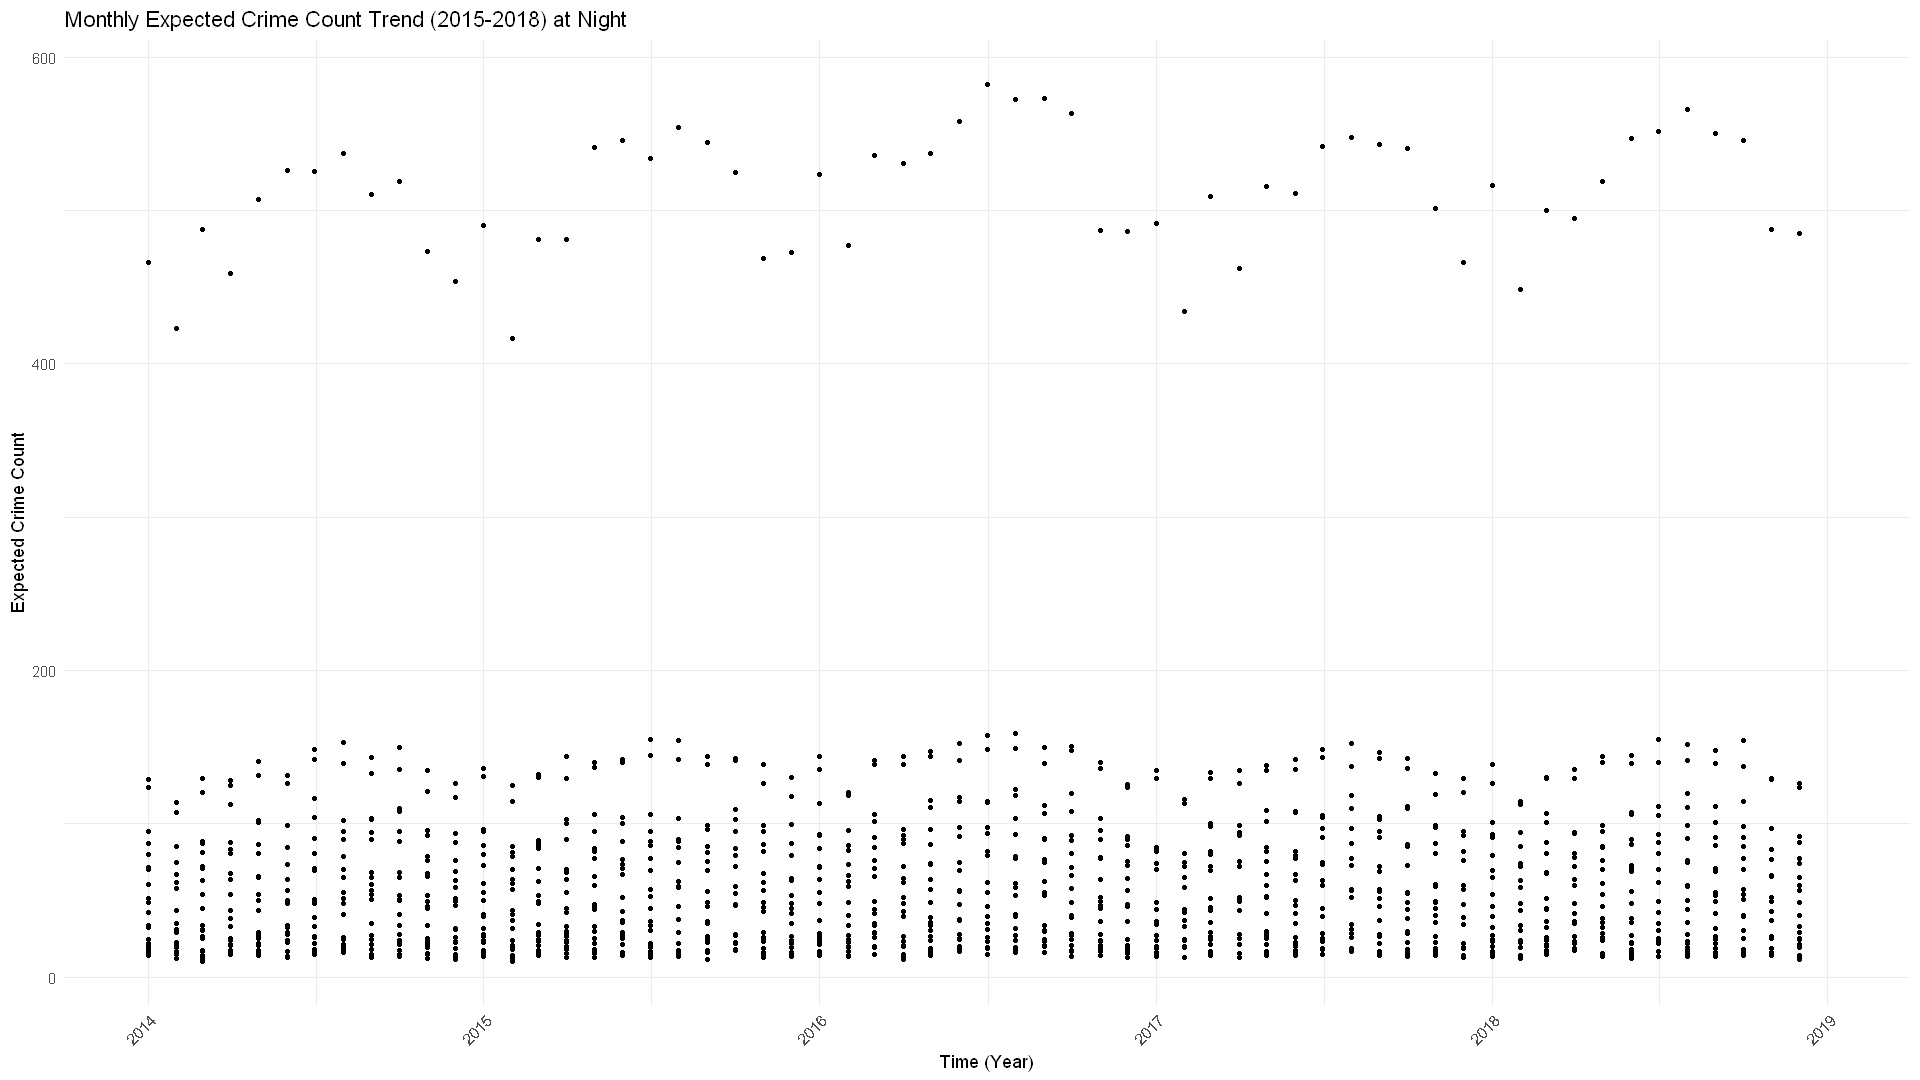

In [78]:
ggplot(neighborhood2016_panel_night, aes(x = date, y = expected_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Crime Count", 
       title = "Monthly Expected Crime Count Trend (2015-2018) at Night") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

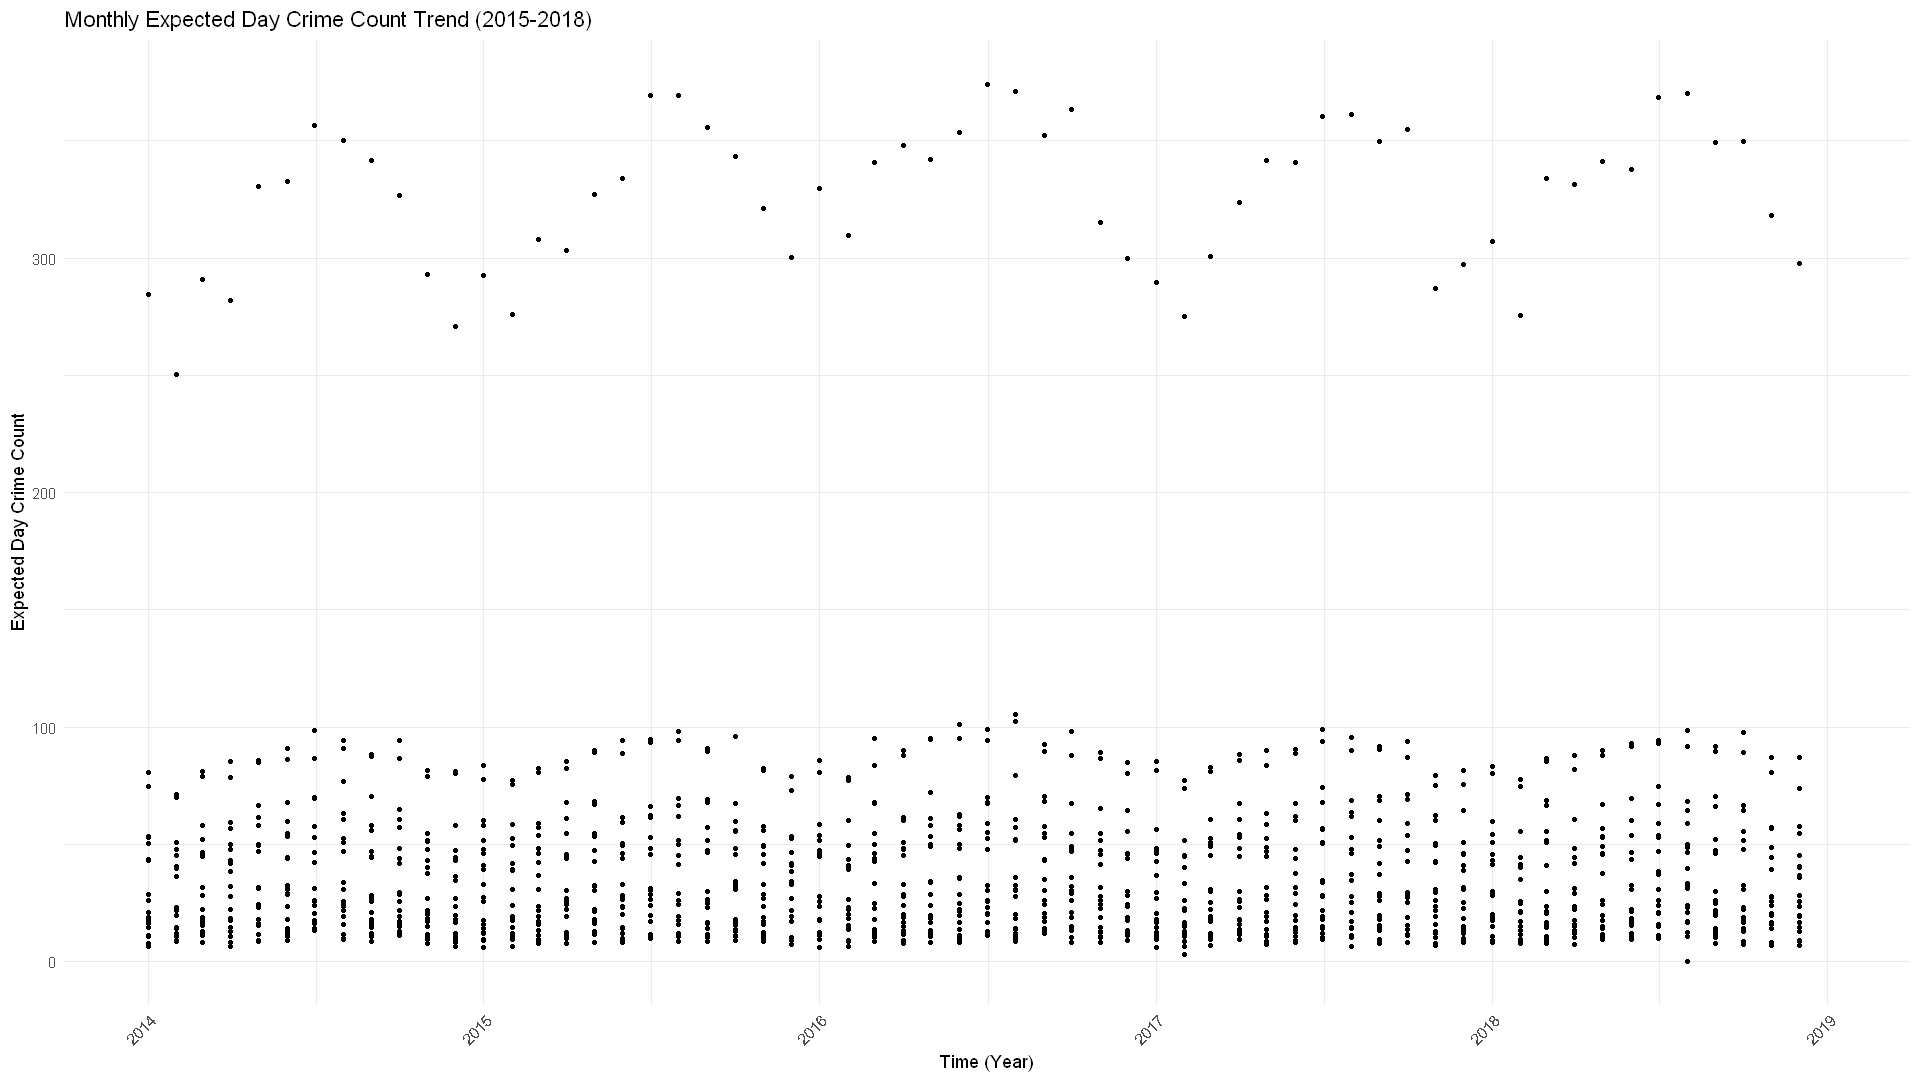

In [79]:
ggplot(neighborhood2016_panel_night, aes(x = date, y = expected_day_crime)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  labs(x = "Time (Year)", y = "Expected Day Crime Count", 
       title = "Monthly Expected Day Crime Count Trend (2015-2018)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"Removed 110 rows containing non-finite outside the scale range
(`stat_smooth()`)."


Warning message:
"Removed 110 rows containing missing values or values outside the scale range
(`geom_point()`)."


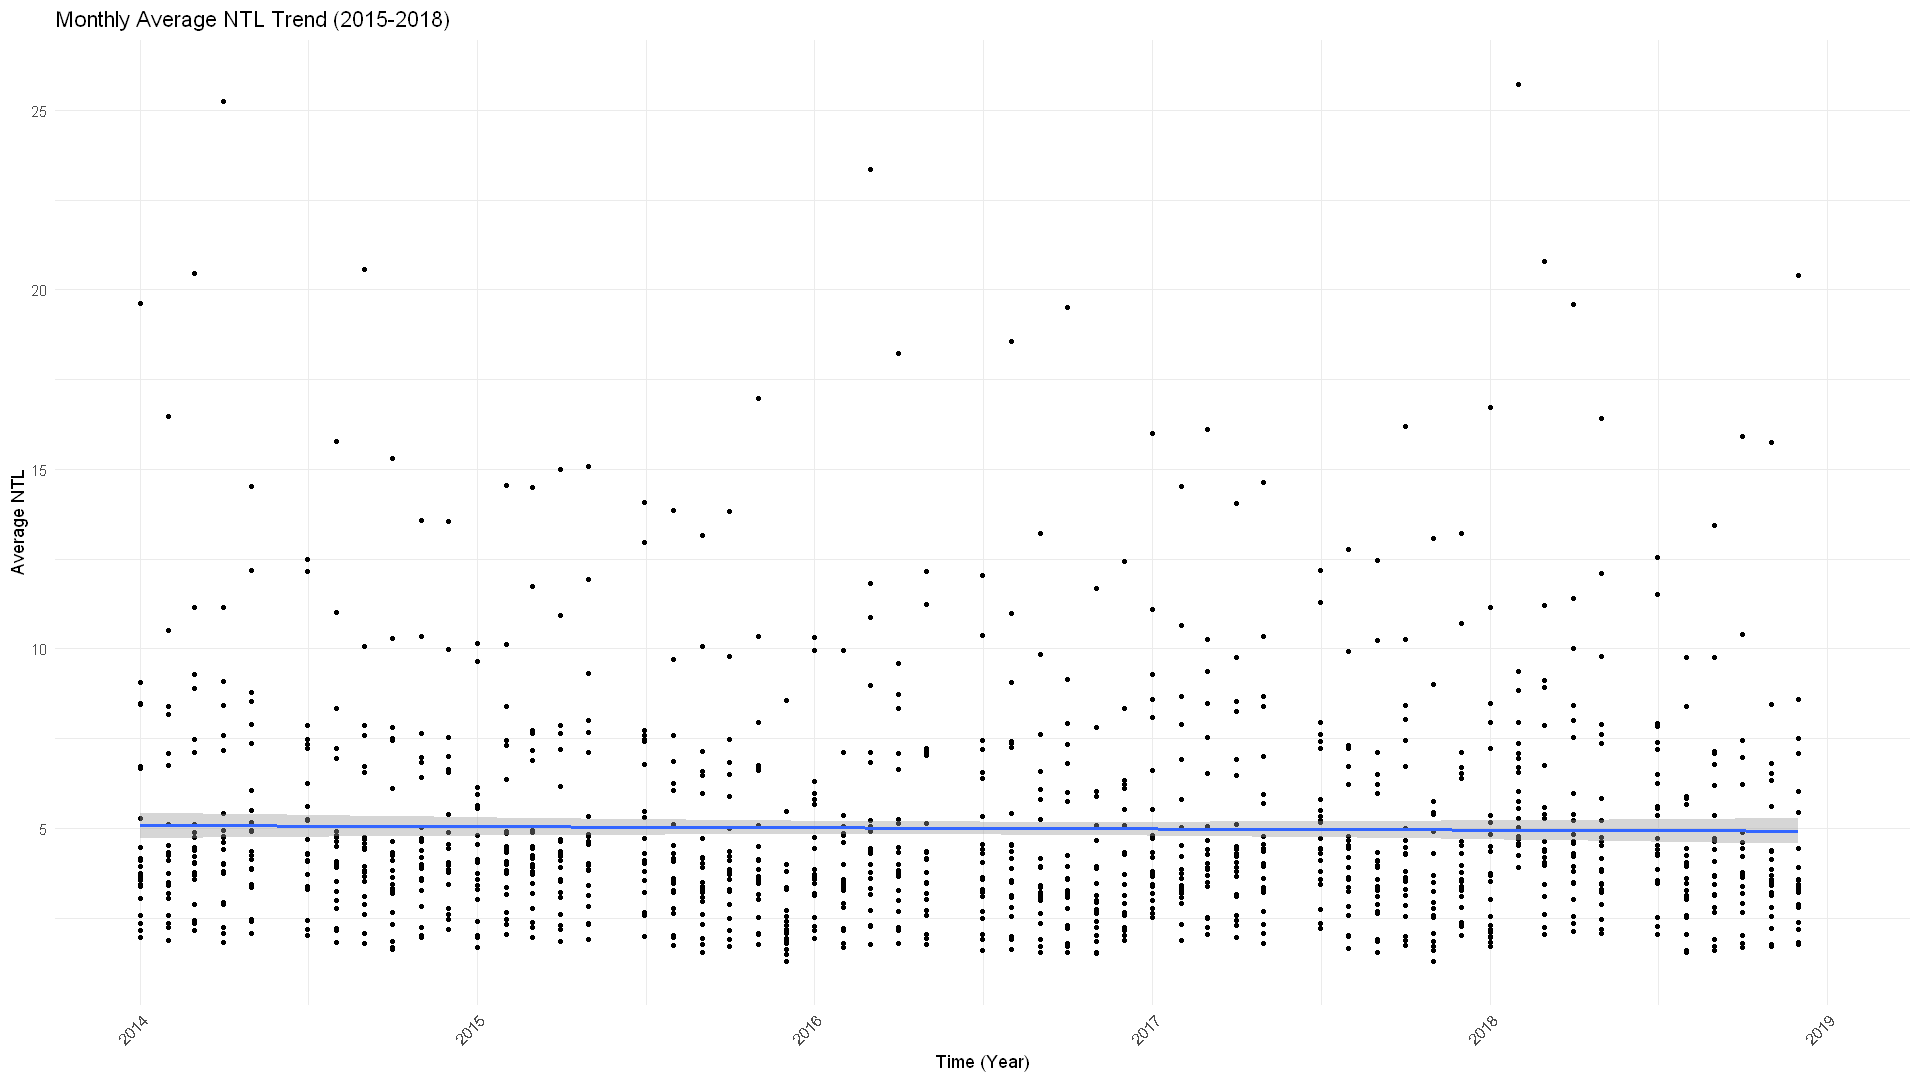

In [80]:
ggplot(neighborhood2016_panel_night, aes(x = date, y = ntl_mean)) +
  geom_point(size = 1) +
  scale_x_date(date_breaks = "1 year", date_labels = "%Y", limits = as.Date(c("2014-01-01", "2018-12-31"))) +
  geom_smooth(method = "lm") + 
  labs(x = "Time (Year)", y = "Average NTL", 
       title = "Monthly Average NTL Trend (2015-2018)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

In [82]:
neighborhood_model0 <- plm(expected_crime ~ ntl_mean * is_downtown + year + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model0)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + year + 
    month, data = neighborhood2016_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 55, N = 1210

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-81.600871  -3.768324  -0.017179   3.423892  59.052459 

Coefficients:
                     Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean              0.21687    0.42730  0.5075 0.6118749    
year2015              1.80631    0.83394  2.1660 0.0305136 *  
year2016              6.47559    0.84476  7.6656 3.719e-14 ***
year2017              1.92633    0.82311  2.3403 0.0194344 *  
year2018              2.69092    0.81688  3.2942 0.0010167 ** 
month10               7.45296    1.21141  6.1523 1.046e-09 ***
month11              -0.45911    1.21987 -0.3764 0.7067149    
month12              -3.20587    1.22515 -2.6167 0.0089925 ** 
month2      

In [96]:
neighborhood_model1 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model1)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    month, data = neighborhood2016_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 55, N = 1210

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-44.368728  -3.248915   0.034093   3.057499  38.121001 

Coefficients:
                      Estimate Std. Error t-value  Pr(>|t|)    
ntl_mean             -0.693647   0.293661 -2.3621   0.01834 *  
expected_day_crime    0.882771   0.025348 34.8260 < 2.2e-16 ***
month10               2.012511   0.885798  2.2720   0.02327 *  
month11              -1.073864   0.877540 -1.2237   0.22130    
month12              -2.387129   0.881553 -2.7079   0.00687 ** 
month2               -4.516870   0.881232 -5.1256 3.465e-07 ***
month3               -0.106451   0.887779 -0.1199   0.90458    
month4               -1.315072   0.882607 -1.4900   0

In [102]:
neighborhood_model2 <- plm(expected_crime ~ ntl_mean * is_downtown + expected_day_crime + month + electric_index + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model2)

Oneway (individual) effect Within Model

Call:
plm(formula = expected_crime ~ ntl_mean * is_downtown + expected_day_crime + 
    month + electric_index + population_density + income, data = neighborhood2016_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 55, N = 1210

Residuals:
     Min.   1st Qu.    Median   3rd Qu.      Max. 
-38.27099  -2.15740   0.20545   2.36707  34.93892 

Coefficients:
                        Estimate  Std. Error t-value  Pr(>|t|)    
ntl_mean             -0.39000489  0.22665257 -1.7207 0.0855662 .  
expected_day_crime    0.84102215  0.01970574 42.6791 < 2.2e-16 ***
month10               1.58964121  0.69029973  2.3028 0.0214630 *  
month11              -2.00283682  0.68549450 -2.9217 0.0035476 ** 
month12              -2.52852984  0.68867994 -3.6716 0.0002519 ***
month2               -3.89235820  0.67981258 -5.7256 1.308e-08 ***
month3               -0.12296855  0.68428159 -0.17

In [98]:
neighborhood_model_log0 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + year + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log0)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    year + month, data = neighborhood2016_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 55, N = 1210

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.6130407 -0.0520244  0.0025762  0.0466785  0.5388894 

Coefficients:
                            Estimate Std. Error t-value  Pr(>|t|)    
log(ntl_mean)             -0.0183147  0.0275132 -0.6657  0.505755    
year2015                   0.0283230  0.0114898  2.4651  0.013841 *  
year2016                   0.0880932  0.0116679  7.5500 8.719e-14 ***
year2017                   0.0298684  0.0112908  2.6454  0.008269 ** 
year2018                   0.0278240  0.0111959  2.4852  0.013087 *  
month10                    0.0929994  0.0166013  5.6019 2.640e-08 ***
month11                   -0.0018283  0.0167333 -0.1093  0.913013    
month12  

In [99]:
neighborhood_model_log1 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + month, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log1)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + month, data = neighborhood2016_panel_night, 
    effect = "individual", model = "within", index = c("neighborhood", 
        "date"))

Balanced Panel: n = 22, T = 55, N = 1210

Residuals:
       Min.     1st Qu.      Median     3rd Qu.        Max. 
-5.7332e-01 -5.6247e-02 -8.8751e-05  5.4883e-02  5.9498e-01 

Coefficients:
                             Estimate  Std. Error t-value  Pr(>|t|)    
log(ntl_mean)             -0.07708009  0.02652616 -2.9058 0.0037317 ** 
expected_day_crime         0.00157492  0.00049093  3.2080 0.0013726 ** 
month10                    0.08273343  0.01720556  4.8085 1.718e-06 ***
month11                   -0.00704122  0.01705641 -0.4128 0.6798143    
month12                   -0.05132360  0.01714541 -2.9934 0.0028163 ** 
month2                    -0.10344360  0.01716280 -6.0272 2.230e-09 ***
month3                     0.023

In [101]:
neighborhood_model_log2 <- plm(log(expected_crime) ~ log(ntl_mean) * is_downtown + expected_day_crime + month + electric_index + population_density + income, 
                            index = c("neighborhood", "date"),
                             data = neighborhood2016_panel_night, 
                             model = "within", 
                             effect = "individual")
                    
summary(neighborhood_model_log2)

Oneway (individual) effect Within Model

Call:
plm(formula = log(expected_crime) ~ log(ntl_mean) * is_downtown + 
    expected_day_crime + month + electric_index + population_density + 
    income, data = neighborhood2016_panel_night, effect = "individual", 
    model = "within", index = c("neighborhood", "date"))

Balanced Panel: n = 22, T = 55, N = 1210

Residuals:
      Min.    1st Qu.     Median    3rd Qu.       Max. 
-0.2714990 -0.0239874 -0.0015138  0.0278676  0.3310908 

Coefficients:
                             Estimate  Std. Error  t-value  Pr(>|t|)    
log(ntl_mean)             -5.2569e-02  1.1816e-02  -4.4490 9.448e-06 ***
expected_day_crime         3.8574e-04  2.2022e-04   1.7517  0.080095 .  
month10                    7.4686e-02  7.7369e-03   9.6532 < 2.2e-16 ***
month11                   -3.0640e-02  7.6866e-03  -3.9861 7.131e-05 ***
month12                   -5.4615e-02  7.7263e-03  -7.0687 2.679e-12 ***
month2                    -8.4364e-02  7.6409e-03 -11.0411 < 2.2e

We check the robustness by running models on crime counts.